In [1]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import joblib as jb
from sklearn.preprocessing import LabelEncoder

In [2]:
## we have dropped exam score bcz it is directly connected to placement

df=pd.read_csv('student_dataset_10000_rows.csv')
x = df.drop(["placement_status", "exam_score"], axis=1)
y = df["placement_status"]

In [3]:
df.head()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed


In [4]:
df.shape

(10000, 8)

In [5]:
corr=df.corr(numeric_only=True)

<Axes: >

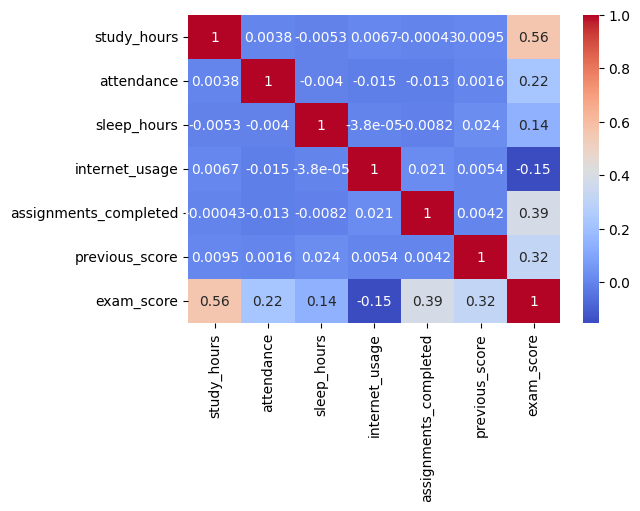

In [6]:
plt.figure(figsize=(6, 4))
sb.heatmap(corr, annot=True, cmap="coolwarm")

<Axes: xlabel='studyhours', ylabel='examscore'>

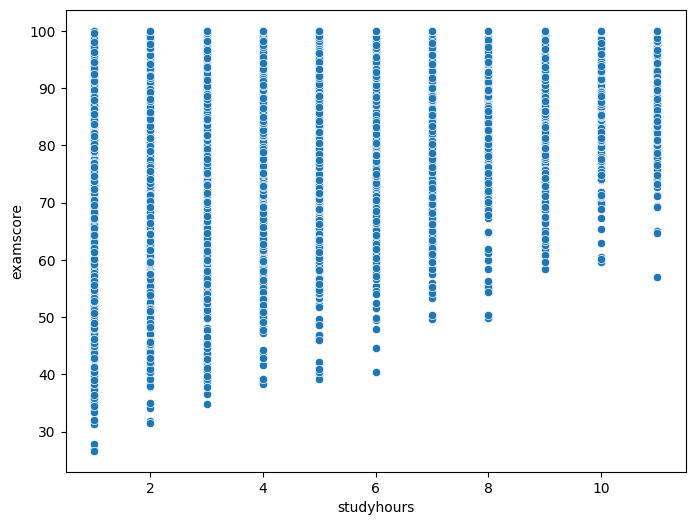

In [7]:
plt.figure(figsize=(8, 6))
plt.xlabel("studyhours")
plt.ylabel("examscore")
sb.scatterplot(x=df.iloc[:,0],y=df.iloc[:,6],data=df)

In [8]:
df.isnull().sum()

study_hours              0
attendance               0
sleep_hours              0
internet_usage           0
assignments_completed    0
previous_score           0
exam_score               0
placement_status         0
dtype: int64

In [9]:
lb=LabelEncoder()

In [10]:
y=lb.fit_transform(y)

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
xtrain,xtest,ytrain,ytest= train_test_split(x,y,test_size=0.25,random_state=0)

In [13]:
from sklearn.ensemble import RandomForestClassifier

In [14]:
rf=RandomForestClassifier(random_state=0)

In [15]:
model=rf.fit(xtrain,ytrain)

In [16]:
ypre=model.predict(xtest)

In [17]:
from sklearn.metrics import accuracy_score,classification_report

In [18]:
accuracy_score(ypre,ytest)

0.8948

In [20]:
print(classification_report(ypre,ytest))

              precision    recall  f1-score   support

           0       0.59      0.72      0.65       334
           1       0.96      0.92      0.94      2166

    accuracy                           0.89      2500
   macro avg       0.77      0.82      0.79      2500
weighted avg       0.91      0.89      0.90      2500



In [22]:
jb.dump(model, "implement_model.pkl")

['implement_model.pkl']